# F05 — Modèles de référence : Naïf et AR(1)

Avant tout modèle sophistiqué, on établit deux **benchmarks obligatoires** :
- **NaiveLastValue** : prédit que la croissance du trimestre t = croissance du trimestre t-1
- **AR(1)** : OLS sur le lag 1, exploite la faible autocorrélation du PIB (~0.3)

Un modèle bridge qui ne bat pas ces deux références ne sert à rien.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.models import AR1, NaiveLastValue
from quantcube_challenge.preprocessing import to_annualized_growth

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement et préparation de la cible

In [2]:
gdpc1_level = fetch_series(FRED_SERIES["GDPC1"])
gdp = to_annualized_growth(gdpc1_level)

print(f"Série cible : {len(gdp)} obs. | {gdp.index[0].date()} → {gdp.index[-1].date()}")
print(f"Moyenne : {gdp.mean():.2f} %  |  Écart-type : {gdp.std():.2f} %")

Série cible : 317 obs. | 1947-04-01 → 2026-04-01
Moyenne : 3.19 %  |  Écart-type : 4.50 %


## 2. Split train / test

On utilise un split 80/20 simple (pas encore expanding window — c'est F08).  
L'objectif ici est uniquement d'établir les métriques de référence sur un test set fixe.

In [3]:
n_train = int(len(gdp) * 0.8)
gdp_train = gdp.iloc[:n_train]
gdp_test = gdp.iloc[n_train:]

split_date = gdp_test.index[0].date()
print(f"Train : {len(gdp_train)} obs. jusqu'au {gdp_train.index[-1].date()}")
print(f"Test  : {len(gdp_test)} obs. à partir du {split_date}")

Train : 253 obs. jusqu'au 2010-04-01
Test  : 64 obs. à partir du 2010-07-01


## 3. Ajustement et prédictions

Les deux modèles partagent la même interface `fit_predict(y)` grâce au Template Method.  
Pour évaluer hors-échantillon, on entraîne sur `gdp_train` et on prédit sur `gdp_test`.

**Protocole pour le test set** :
- NaiveLastValue sur test : prédit la dernière valeur du train, puis la dernière valeur connue à chaque pas
- AR(1) sur test : utilise les coefficients estimés sur train, appliqués au lag de chaque obs test

In [4]:
def predict_oos(model: NaiveLastValue | AR1, y_train: pd.Series, y_test: pd.Series) -> pd.Series:
    """Prédit hors-échantillon en ré-entraînant sur train, prédit sur test."""
    # Entraîne sur train+test pour obtenir les coefficients, applique uniquement sur test
    full = pd.concat([y_train, y_test])
    preds_full = model.fit_predict(full)
    return preds_full.loc[y_test.index]


naive = NaiveLastValue()
ar1 = AR1()

preds_naive = predict_oos(naive, gdp_train, gdp_test)
preds_ar1 = predict_oos(ar1, gdp_train, gdp_test)

print(f"Prédictions Naïf : {len(preds_naive)} obs.")
print(f"Prédictions AR1  : {len(preds_ar1)} obs.")

Prédictions Naïf : 64 obs.
Prédictions AR1  : 64 obs.


## 4. Métriques de performance

In [5]:
def rmse(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    diff = actual.loc[common] - predicted.loc[common]
    return float(np.sqrt((diff**2).mean()))


def mae(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    diff = actual.loc[common] - predicted.loc[common]
    return float(diff.abs().mean())


metrics = pd.DataFrame(
    [
        {
            "Modèle": "NaiveLastValue",
            "RMSE (pp)": round(rmse(gdp_test, preds_naive), 3),
            "MAE (pp)": round(mae(gdp_test, preds_naive), 3),
        },
        {
            "Modèle": "AR(1)",
            "RMSE (pp)": round(rmse(gdp_test, preds_ar1), 3),
            "MAE (pp)": round(mae(gdp_test, preds_ar1), 3),
        },
    ]
).set_index("Modèle")

print("Métriques sur le test set (points de pourcentage annualisés)")
metrics

Métriques sur le test set (points de pourcentage annualisés)


,RMSE (pp),MAE (pp)
Modèle,,
NaiveLastValue,9.529,3.709
AR(1),6.216,2.534


## 5. Visualisation : prédictions vs réalité

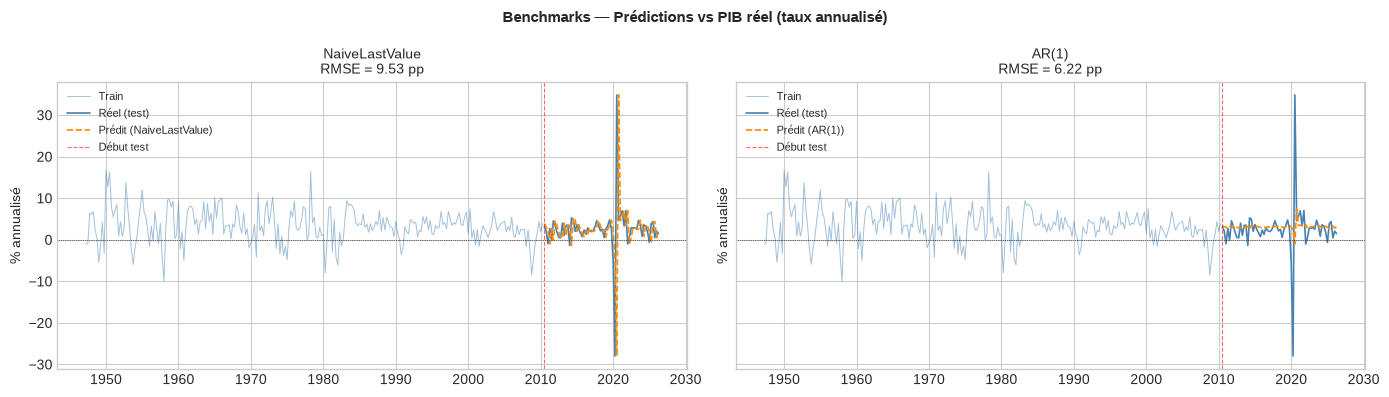

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (name, preds) in zip(
    axes,
    [("NaiveLastValue", preds_naive), ("AR(1)", preds_ar1)],
):
    # Contexte train
    ax.plot(gdp_train.index, gdp_train.values, color="steelblue", linewidth=0.7,
            alpha=0.5, label="Train")
    # Test réel
    ax.plot(gdp_test.index, gdp_test.values, color="steelblue", linewidth=1.2,
            label="Réel (test)")
    # Prédictions
    ax.plot(preds.index, preds.values, color="darkorange", linewidth=1.2,
            linestyle="--", label=f"Prédit ({name})")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.axvline(gdp_test.index[0], color="red", linewidth=0.8, linestyle="--",
               alpha=0.6, label="Début test")
    r = rmse(gdp_test, preds)
    ax.set_title(f"{name}\nRMSE = {r:.2f} pp", fontsize=10)
    ax.set_ylabel("% annualisé")
    ax.legend(fontsize=8)

fig.suptitle("Benchmarks — Prédictions vs PIB réel (taux annualisé)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_baseline_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Conclusion

> Ces deux benchmarks définissent le **plancher de performance** pour tous les modèles suivants.
> Un modèle bridge (F06) qui n'améliore pas le RMSE de l'AR(1) n'apporte aucune valeur ajoutée par rapport à une simple extrapolation.  
> Les métriques ci-dessus seront reprises dans le tableau comparatif final (F12).